# RETO 3: CLASIFICACION DE FLORES

### Importar librerías

In [1]:
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay, classification_report

### Traer y leer Dataset

In [2]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])
df_iris = df_iris.dropna()
le = LabelEncoder()
df_iris["Clase"] = le.fit_transform(df_iris["Clase"])

In [3]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

     Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo  Clase
0             5.1           3.5           1.4           0.2      0
1             4.9           3.0           1.4           0.2      0
2             4.7           3.2           1.3           0.2      0
3             4.6           3.1           1.5           0.2      0
4             5.0           3.6           1.4           0.2      0
..            ...           ...           ...           ...    ...
145           6.7           3.0           5.2           2.3      2
146           6.3           2.5           5.0           1.9      2
147           6.5           3.0           5.2           2.0      2
148           6.2           3.4           5.4           2.3      2
149           5.9           3.0           5.1           1.8      2

[150 rows x 5 columns]
   Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo  Clase
0           5.1           3.5           1.4           0.2      0
1           4.9           3.0           1.

## <span style="color:yellow">K-Means</span>

### Separar X (no usamos Y para entrenar)

In [5]:
X_kmeans = df_iris.drop("Clase", axis=1).copy()
y_real = df_iris["Clase"].copy()  # solo para evaluar

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

### Método del codo

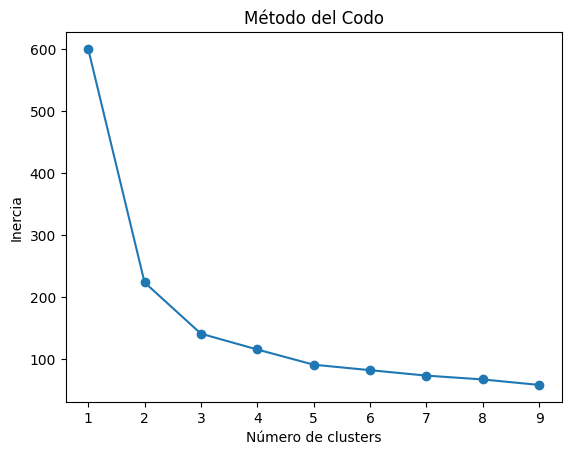

In [6]:
inercia = []

for k in range(1, 10):
    modelo = KMeans(n_clusters=k, random_state=28)
    modelo.fit(X_kmeans_scaled)
    inercia.append(modelo.inertia_)

plt.plot(range(1,10), inercia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

### Entrenar modelo logístico, predicciones

In [7]:
modelo_kmeans = KMeans(n_clusters=3, random_state=28)
modelo_kmeans.fit(X_kmeans_scaled)


KMeans(n_clusters=3, random_state=28)

### Alinear clusters

In [8]:
clusters = modelo_kmeans.labels_
pred_alineado = np.zeros_like(clusters)
for i in range(3):
    
    mask = (clusters == i)
    
    pred_alineado[mask] = mode(y_real[mask], keepdims=True)[0]

In [9]:
pred_kmeans = modelo_kmeans.predict(X_kmeans_scaled)
silhouette = silhouette_score(X_kmeans_scaled, pred_kmeans)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.46214947389312017


### Validaciones

In [10]:
silhouette_scores = []

for k in range(2,10):
    
    modelo = KMeans(n_clusters=k, random_state=28)
    modelo.fit(X_kmeans_scaled)
    
    labels = modelo.labels_
    
    score = silhouette_score(X_kmeans_scaled, labels)
    
    silhouette_scores.append(score)
    
    print(f"Con K = {k}  ->  accuracy = {score}")

Con K = 2  ->  accuracy = 0.580184463257396
Con K = 3  ->  accuracy = 0.46214947389312017
Con K = 4  ->  accuracy = 0.4140182611396695
Con K = 5  ->  accuracy = 0.34805236242232845
Con K = 6  ->  accuracy = 0.3212444922846655
Con K = 7  ->  accuracy = 0.3216777898636184
Con K = 8  ->  accuracy = 0.3223096968843314
Con K = 9  ->  accuracy = 0.32875873260110167


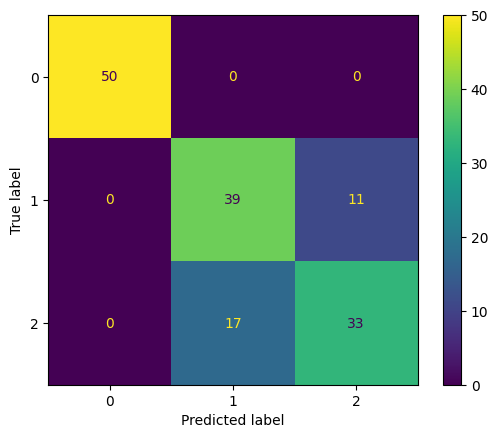

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.70      0.78      0.74        50
           2       0.75      0.66      0.70        50

    accuracy                           0.81       150
   macro avg       0.82      0.81      0.81       150
weighted avg       0.82      0.81      0.81       150



In [11]:
ConfusionMatrixDisplay.from_predictions(y_real, pred_alineado)
plt.show()

print(classification_report(y_real, pred_alineado))

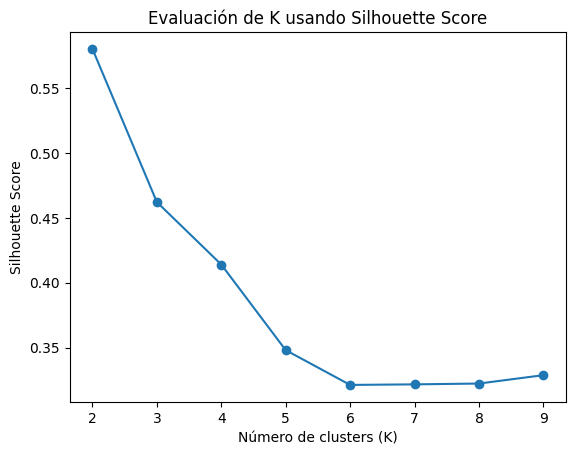

In [12]:
k_values = range(2,10)

plt.plot(k_values, silhouette_scores, marker='o')

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación de K usando Silhouette Score")

plt.show()

### Cambiar Hiperparametros

Mejores parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4, 'n_init': 20} con precisión realista de: 0.42666666666666664
Silhouette Score después de optimizar hiperparámetros: 0.38949665339898654


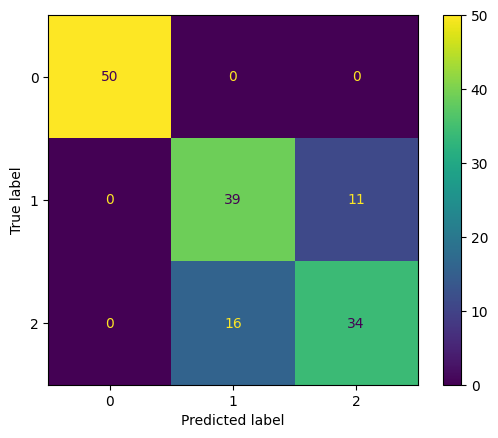

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.71      0.78      0.74        50
           2       0.76      0.68      0.72        50

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150



In [20]:
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++'],
    'n_init': [20, 30, 50, 100],
    'max_iter': [300, 500, 1000]
}

grid_kmeans = GridSearchCV(
    KMeans(random_state=28),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_kmeans.fit(X_kmeans_scaled, y_real)
best_kmeans = grid_kmeans.best_estimator_
clusters_best = best_kmeans.labels_
print(f"Mejores parámetros: {grid_kmeans.best_params_} con precisión realista de: {grid_kmeans.best_score_}")

silhouette_best = silhouette_score(X_kmeans_scaled, clusters_best)

print("Silhouette Score después de optimizar hiperparámetros:", silhouette_best)

pred_alineado_best = np.zeros_like(clusters_best)

for i in range(best_kmeans.n_clusters):

    mask = (clusters_best == i)

    pred_alineado_best[mask] = mode(y_real[mask], keepdims=True)[0]
    
ConfusionMatrixDisplay.from_predictions(y_real, pred_alineado_best)
plt.show()

print(classification_report(y_real, pred_alineado_best))

## <span style="color:yellow">Perceptron Multicapa</span>

### Separar X, y, entrenamiento y pruebas

In [4]:
X_mlp = df_iris.drop("Clase", axis=1).copy()
y_mlp = df_iris["Clase"].copy()

scaler = StandardScaler()
X_mlp_scaled = scaler.fit_transform(X_mlp)

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp_scaled, y_mlp, test_size=0.3, random_state=28
)

### Entrenar modelo y predicciones

In [5]:
modelo_mlp = MLPClassifier(random_state=28, max_iter=1000)

modelo_mlp.fit(X_train_mlp, y_train_mlp)

pred_mlp = modelo_mlp.predict(X_test_mlp)

### Validaciones

Accuracy MLP: 0.9555555555555556


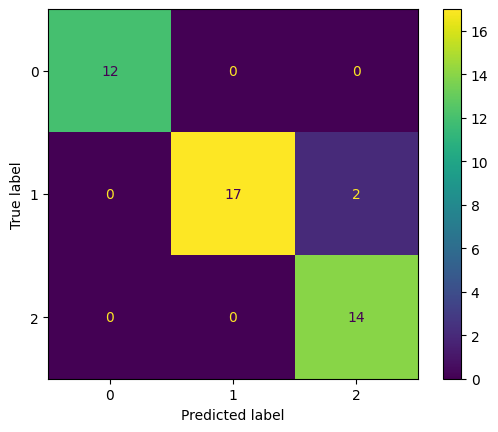

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.89      0.94        19
           2       0.88      1.00      0.93        14

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [6]:
accuracy_mlp = accuracy_score(y_test_mlp, pred_mlp)
print("Accuracy MLP:", accuracy_mlp)

ConfusionMatrixDisplay.from_predictions(y_test_mlp, pred_mlp)
plt.show()

print(classification_report(y_test_mlp, pred_mlp))

### Cambiar Hiperparametros

Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant'} con precisión realista de: 0.9523809523809523
Precision en test:  0.9555555555555556
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.89      0.94        19
           2       0.88      1.00      0.93        14

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



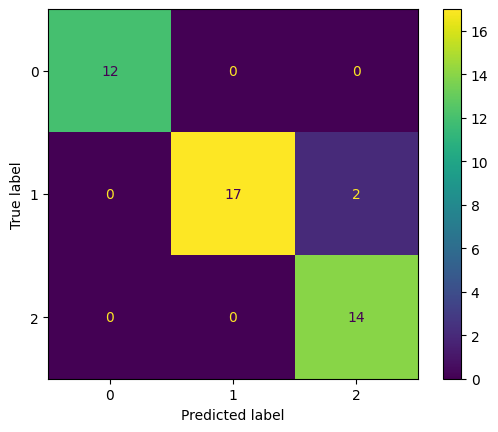

In [7]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,30), (100,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=28),
    param_grid_mlp,
    cv=5,
    scoring='accuracy'
)

grid_mlp.fit(X_train_mlp, y_train_mlp)

print(f"Mejores parámetros: {grid_mlp.best_params_} con precisión realista de: {grid_mlp.best_score_}")

pred_mlp_grid = grid_mlp.predict(X_test_mlp)
best_mlp = grid_mlp.best_estimator_
pred_best_mlp = best_mlp.predict(X_test_mlp)

print("Precision en test: ", accuracy_score(y_test_mlp, pred_mlp_grid))
print(classification_report(y_test_mlp, pred_mlp_grid))

ConfusionMatrixDisplay.from_predictions(y_test_mlp, pred_mlp_grid)
plt.show()

In [30]:


print("Accuracy optimizado:", accuracy_score(y_test_mlp, pred_best_mlp))

Accuracy optimizado: 0.9555555555555556


## <span style="color:red">Conclusiones</span>

<p>De lo obsevado podemos observar lo siguiente:</p>

<ul>
    <li>
        El modelo <strong>Kmeans</strong> en su forma predeterminada alcanzó una exactitud de ~46%, siendo el accuracy mas alto, a pesar de que en el proceso de optimización se evaluaron diferentes configuraciones de número de clusters, método de inicialización, número de reinicializaciones y número máximo de iteraciones, ninguna combinación logró mejorar el accuracy de su forma predeterminada, por lo cual se concluye que la optimización de hiperparámetros no siempre garantiza una mejora en el desempeño del modelo, especialmente en algoritmos de aprendizaje no supervisado como K-means, donde la calidad del clustering depende principalmente de la estructura intrínseca de los datos.
    </li>
    <li>
        Otra conclusión que podemos sacar del modelo <strong>Kmeans</strong> es que el hecho de que el modelo optimizado presente un Silhouette Score menor indica que las combinaciones de hiperparámetros exploradas no lograron generar clusters con mayor separación y cohesión que los obtenidos con los parámetros por defecto. Esto debido a que el conjunto de datos ya presenta una estructura natural relativamente clara, por lo que el modelo inicial se encuentra cerca de una solución óptima.
    <li>
        El modelo <strong>Perceptrón Multicapa</strong> en su forma básica obtuvo una precisión de ~95% incluso sin modificar ningun parámetro, indicando que el dataset es relativamente fácil de separar. En estas condiciones, el modelo predice mal dos flores como Virginica que deberían ser Versicolor.
    </li>
    <li>
        Para el modelo <strong>Perceptrón Multicapa</strong> los hiperparámetros evaluados son :hidden_layer_sizes, activation, alpha y learning_rate. El parámetro hidden_layer_sizes define la arquitectura de la red neuronal, es decir, el número de capas ocultas y la cantidad de neuronas en cada una, lo que determina la capacidad del modelo para aprender patrones complejos en los datos. El hiperparámetro activation corresponde a la función de activación utilizada por las neuronas, la cual introduce no linealidad en el modelo y permite representar relaciones más complejas entre las variables de entrada. Por su parte, alpha controla el nivel de regularización L2 aplicado a los pesos de la red, lo cual ayuda a evitar el sobreajuste penalizando valores excesivamente grandes en los parámetros del modelo. Finalmente, learning_rate determina la forma en que se ajusta la tasa de aprendizaje durante el entrenamiento, influyendo en la velocidad con la que el algoritmo converge hacia una solución. A pesar de explorar distintas combinaciones de estos hiperparámetros mediante validación cruzada, el modelo optimizado obtuvo el mismo nivel de precisión que el modelo con parámetros predeterminados.
    </li>
    <li>
        En consecuencia, el hecho de que el modelo optimizado presente exactamente el mismo accuracy que el modelo por defecto no indica un fallo en el proceso de optimización, sino que sugiere que el modelo inicial ya se encontraba cercano a una solución óptima para este conjunto de datos. Esto evidencia que, en problemas de baja complejidad, el perceptrón multicapa puede alcanzar altos niveles de precisión incluso sin una optimización intensiva de hiperparámetros.
    </li>
</ul>